In [ ]:
!pip install pretty_midi

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import pretty_midi
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import IPython.display as ipd

%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
melody_files = set(os.listdir("processed/melodies_all"))
drum_files = set(os.listdir("processed/drums_all"))
bass_files = set(os.listdir("processed/bass_all"))

matched_files = sorted(list(melody_files & drum_files & bass_files))

print("melody files:", len(melody_files))
print("drum files:", len(drum_files))
print("bass files:", len(bass_files))
print("matched melody+drum+bass:", len(matched_files))
print(matched_files[:10])

melody files: 333
drum files: 338
bass files: 334
matched melody+drum+bass: 328
['ABC__4_Ever_2_Gether.mid', 'ABC__Look_of_Love,_Part_1.mid', 'ABC__Poison_Arrow.mid', 'Bronski_Beat__Small_Town_Boy.mid', 'Culture_Club__Church_of_the_Poison_Mind.mid', 'Culture_Club__Do_You_Really_Want_to_Hurt_Me.1.mid', 'Culture_Club__Do_You_Really_Want_to_Hurt_Me.mid', 'Depeche_Mode__Barrel_Of_A_Gun.mid', 'Depeche_Mode__Black_Celebration.1.mid', 'Depeche_Mode__Black_Celebration.2.mid']


In [5]:
import pandas as pd

bpm_df = pd.read_csv("processed/bpm_data.csv")
melody_df = pd.read_csv("processed/melody_dataset.csv")
drum_df = pd.read_csv("processed/drum_dataset.csv")
bass_df = pd.read_csv("processed/bass_dataset.csv")
usable_df = pd.read_csv("processed/usable_songs.csv")

display(bpm_df.head())
display(melody_df.head())
display(drum_df.head())
display(bass_df.head())
display(usable_df.head())

,artist,song,bpm
0,ABC,Poison Arrow.mid,126.000126
1,ABC,4 Ever 2 Gether.mid,89.999955
2,ABC,"Look of Love, Part 1.mid",120.999944
3,Bronski Beat,Small Town Boy.mid,126.999985
4,Culture Club,Do You Really Want to Hurt Me.mid,104.000014


,artist,song,original_path,melody_path,instrument_program,instrument_name,track_name,n_notes,avg_pitch,bpm
0,ABC,4 Ever 2 Gether.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,75,Pan Flute,NaN,564,72.044326,89.999955
1,ABC,"Look of Love, Part 1.mid",/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,62,Synth Brass 1,Vocals,350,60.945714,120.999944
2,ABC,Poison Arrow.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,71,Clarinet,Melody & Lyric,339,61.218289,126.000126
3,Bronski Beat,Small Town Boy.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,73,Flute,Vocal,607,75.752883,126.999985
4,Culture Club,Church of the Poison Mind.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,61,Brass Section,NaN,75,72.920000,130.000130


,artist,song,original_path,drum_path,n_drum_tracks_merged,n_notes,n_unique_drums,bpm,duration
0,ABC,4 Ever 2 Gether.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,1,3214,13,89.999955,207.430659
1,ABC,"Look of Love, Part 1.mid",/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,1,1714,14,120.999944,208.128196
2,ABC,Poison Arrow.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,1,2263,15,126.000126,202.936305
3,Bronski Beat,Small Town Boy.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,1,2931,9,126.999985,310.551688
4,Culture Club,Church of the Poison Mind.mid,/Users/donghyunhahn/Desktop/spring 2026/cse 15...,/Users/donghyunhahn/Documents/GitHub/synth_mus...,2,2533,7,130.000130,238.109137


,artist,song,bass_path,instrument_program,instrument_name,n_notes,avg_pitch,bpm
0,ABC,4 Ever 2 Gether.mid,ABC__4_Ever_2_Gether.mid,35,Fretless Bass,518,39.888031,89.999955
1,ABC,"Look of Love, Part 1.mid","ABC__Look_of_Love,_Part_1.mid",39,Synth Bass 2,590,30.893220,120.999944
2,ABC,Poison Arrow.mid,ABC__Poison_Arrow.mid,33,Electric Bass (finger),613,36.226754,126.000126
3,Bronski Beat,Small Town Boy.mid,Bronski_Beat__Small_Town_Boy.mid,35,Fretless Bass,1344,43.407738,126.999985
4,Culture Club,Church of the Poison Mind.mid,Culture_Club__Church_of_the_Poison_Mind.mid,35,Fretless Bass,699,36.633763,130.000130


,artist,song,bpm,has_drums,n_drum_notes,n_total_tracks,filepath
0,ABC,4 Ever 2 Gether.mid,89.999955,True,3214,11,/Users/donghyunhahn/Desktop/spring 2026/cse 15...
1,ABC,"Look of Love, Part 1.mid",120.999944,True,1714,16,/Users/donghyunhahn/Desktop/spring 2026/cse 15...
2,ABC,Poison Arrow.mid,126.000126,True,2263,14,/Users/donghyunhahn/Desktop/spring 2026/cse 15...
3,Bronski Beat,Small Town Boy.mid,126.999985,True,2931,12,/Users/donghyunhahn/Desktop/spring 2026/cse 15...
4,Culture Club,Church of the Poison Mind.mid,130.000130,True,2533,14,/Users/donghyunhahn/Desktop/spring 2026/cse 15...


## Helper Functions and Symbolic Representation Utilities

This section defines the core constants and helper functions used throughout the symbolic synth-pop preprocessing pipeline.

These utilities are responsible for:

```text
1. Defining symbolic music representations
2. Converting MIDI notes into discrete time grids
3. Extracting BPM information
4. Mapping drum MIDI pitches into simplified drum classes

In [6]:
STEPS_PER_BAR = 16
BARS_PER_SEGMENT = 4
TOTAL_STEPS = STEPS_PER_BAR * BARS_PER_SEGMENT
REST_TOKEN = 0

DRUM_MAP = {
    36: 0, 35: 0,  # kick
    38: 1, 40: 1,  # snare
    42: 2, 44: 2, 46: 2  # hi-hat
}

def get_first_bpm(midi_path, fallback=120):
    pm = pretty_midi.PrettyMIDI(midi_path)
    _, tempi = pm.get_tempo_changes()
    if len(tempi) == 0:
        return fallback
    return float(tempi[0])

def step_sec_from_bpm(bpm):
    return (60.0 / bpm) / 4

def pitch_notes_to_grid(notes, start_time, step_sec, num_steps):
    grid = np.zeros(num_steps, dtype=np.int64)

    for note in notes:
        step = int(round((note.start - start_time) / step_sec))
        if 0 <= step < num_steps:
            grid[step] = note.pitch + 1

    return grid

def drum_notes_to_grid(notes, start_time, step_sec, num_steps):
    grid = np.zeros((num_steps, 3), dtype=np.int64)

    for note in notes:
        step = int(round((note.start - start_time) / step_sec))
        if 0 <= step < num_steps and note.pitch in DRUM_MAP:
            grid[step, DRUM_MAP[note.pitch]] = 1

    return grid

## MIDI Segment Extraction

The function `midi_triplet_to_segments()` converts separated MIDI tracks into usable training samples for the conditional accompaniment generation model.

Each song is represented using:

- Melody MIDI track
- Drum MIDI track
- Bass MIDI track
- BPM information

The goal is to create paired 4-bar training samples where the model can learn:

```text
Input:
melody + BPM

Targets:
bassline + drum groove

In [7]:
def midi_triplet_to_segments(
    melody_path,
    drum_path,
    bass_path,
    bpm=None,
    min_melody_notes=8,
    min_drum_hits=8,
    min_bass_notes=4
):
    melody_pm = pretty_midi.PrettyMIDI(melody_path)
    drum_pm = pretty_midi.PrettyMIDI(drum_path)
    bass_pm = pretty_midi.PrettyMIDI(bass_path)

    if bpm is None:
        bpm = get_first_bpm(melody_path)

    step_sec = step_sec_from_bpm(bpm)
    segment_sec = step_sec * TOTAL_STEPS

    melody_notes = []
    for inst in melody_pm.instruments:
        melody_notes.extend(inst.notes)

    drum_notes = []
    for inst in drum_pm.instruments:
        drum_notes.extend(inst.notes)

    bass_notes = []
    for inst in bass_pm.instruments:
        bass_notes.extend(inst.notes)

    end_time = max(
        melody_pm.get_end_time(),
        drum_pm.get_end_time(),
        bass_pm.get_end_time()
    )

    segments = []
    start_time = 0.0

    while start_time + segment_sec <= end_time:
        melody_grid = pitch_notes_to_grid(
            melody_notes,
            start_time,
            step_sec,
            TOTAL_STEPS
        )

        drum_grid = drum_notes_to_grid(
            drum_notes,
            start_time,
            step_sec,
            TOTAL_STEPS
        )

        bass_grid = pitch_notes_to_grid(
            bass_notes,
            start_time,
            step_sec,
            TOTAL_STEPS
        )

        if (
            np.count_nonzero(melody_grid) >= min_melody_notes
            and drum_grid.sum() >= min_drum_hits
            and np.count_nonzero(bass_grid) >= min_bass_notes
        ):
            segments.append({
                "melody": melody_grid,
                "drums": drum_grid,
                "bass": bass_grid,
                "bpm": bpm,
                "start_time": start_time
            })

        start_time += segment_sec

    return segments

## Final Dataset Construction

After extracting usable 4-bar segments from each MIDI pair, all samples are collected into unified NumPy arrays for model training.

The preprocessing loop iterates through every matched melody/drum MIDI pair:

```python
for fname in matched_files:

In [8]:
all_melodies = []
all_drums = []
all_bass = []
all_bpms = []
all_files = []
all_start_times = []

melody_files = set(os.listdir("processed/melodies_all"))
drum_files = set(os.listdir("processed/drums_all"))
bass_files = set(os.listdir("processed/bass_all"))

matched_files = sorted(list(melody_files & drum_files & bass_files))

for fname in matched_files:
    melody_path = os.path.join("processed/melodies_all", fname)
    drum_path = os.path.join("processed/drums_all", fname)
    bass_path = os.path.join("processed/bass_all", fname)

    try:
        segments = midi_triplet_to_segments(
            melody_path,
            drum_path,
            bass_path,
            min_melody_notes=8,
            min_drum_hits=8,
            min_bass_notes=4
        )

        for seg in segments:
            all_melodies.append(seg["melody"])
            all_drums.append(seg["drums"])
            all_bass.append(seg["bass"])
            all_bpms.append(seg["bpm"])
            all_files.append(fname)
            all_start_times.append(seg["start_time"])

    except Exception as e:
        print("Skipping", fname, "because", e)

all_melodies = np.array(all_melodies)
all_drums = np.array(all_drums)
all_bass = np.array(all_bass)
all_bpms = np.array(all_bpms)

print("melodies:", all_melodies.shape)
print("drums:", all_drums.shape)
print("bass:", all_bass.shape)
print("bpms:", all_bpms.shape)
print("num samples:", len(all_melodies))

melodies: (4462, 64)
drums: (4462, 64, 3)
bass: (4462, 64)
bpms: (4462,)
num samples: 4462


## Saving the Final Training Dataset

After preprocessing all MIDI files and extracting usable 4-bar segments, the complete dataset is saved into a compressed NumPy archive (`.npz` file).

```python
np.savez(
    "processed/task2_bass_drum_dataset_4bar.npz",
    melodies=all_melodies,
    drums=all_drums,
    bass=all_bass,
    bpms=all_bpms,
    files=np.array(all_files),
    start_times=np.array(all_start_times)
)

In [9]:
np.savez(
    "processed/task2_bass_drum_dataset_4bar.npz",
    melodies=all_melodies,
    drums=all_drums,
    bass=all_bass,
    bpms=all_bpms,
    files=np.array(all_files),
    start_times=np.array(all_start_times)
)

## Dataset Source

The dataset is built on the **Lakh MIDI Dataset (LMD)** (Raffel, 2016), a large-scale
collection of ~176,000 MIDI files aligned to the Million Song Dataset.

From this corpus, a synth-pop subset was curated by filtering tracks from representative
80s artists including **Depeche Mode, Culture Club, ABC, Bronski Beat**, and others.

For each song, three tracks were automatically extracted:
- **Melody**: selected by scoring instruments on pitch range, note density, and monophony
- **Drum**: identified via MIDI channel 9 (`is_drum=True`), merged if multiple tracks existed
- **Bass**: identified by instrument name containing "bass" or program number 32–39 (GM bass instruments)

Only songs containing all three tracks were retained for training.

### Dataset Statistics
```text
Melody files:            333
Drum files:              338
Bass files:              334
Matched songs (all 3):   328
4-bar segments:          4,462
BPM range:               ~90–130 BPM
Segment length:          64 steps (16 steps/bar × 4 bars)
Drum classes:            kick (MIDI 35/36), snare (38/40), hi-hat (42/44/46)
Bass pitch range:        MIDI 28–50 (E1–D3, typical synth-pop bass)


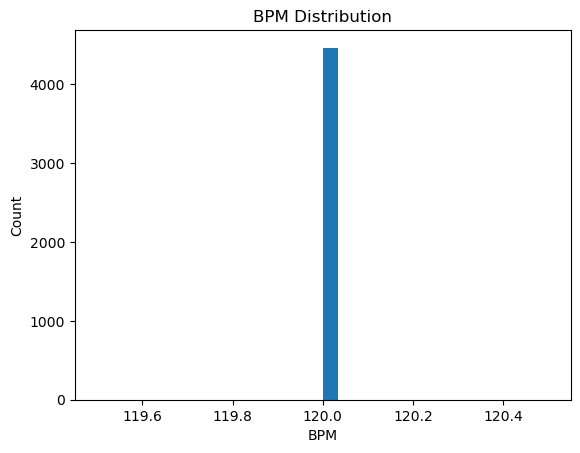

In [10]:

plt.hist(all_bpms, bins=30)
plt.title("BPM Distribution")
plt.xlabel("BPM")
plt.ylabel("Count")
plt.show()

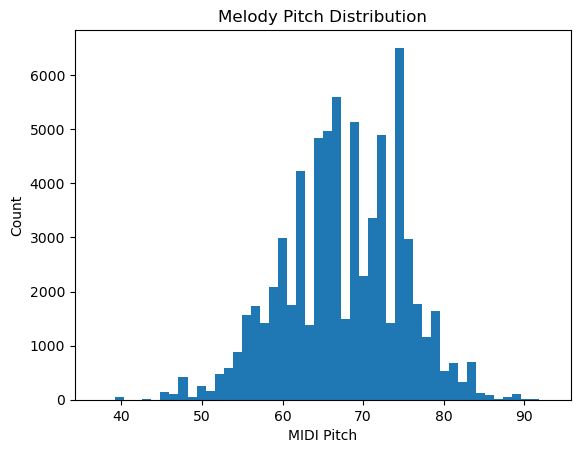

In [11]:
all_pitches = all_melodies.flatten()
all_pitches = all_pitches[all_pitches > 0] - 1

plt.hist(all_pitches, bins=50)
plt.title("Melody Pitch Distribution")
plt.xlabel("MIDI Pitch")
plt.ylabel("Count")
plt.show()

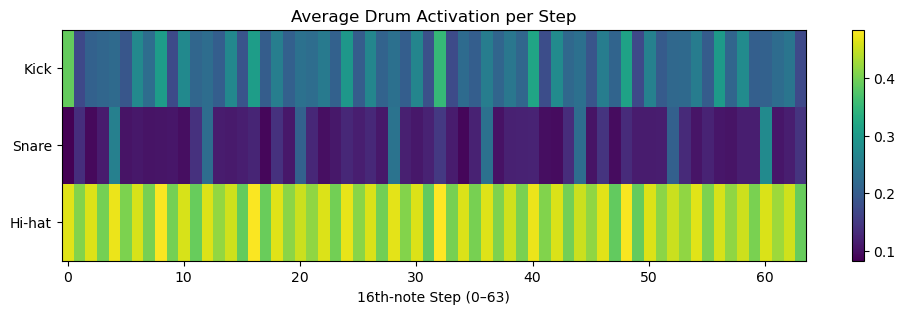

In [12]:
avg_drum = all_drums.mean(axis=0).T   # shape: (3, 64)
plt.figure(figsize=(12, 3))
plt.imshow(avg_drum, aspect='auto')
plt.yticks([0, 1, 2], ["Kick", "Snare", "Hi-hat"])
plt.xlabel("16th-note Step (0–63)")
plt.title("Average Drum Activation per Step")
plt.colorbar()
plt.show()

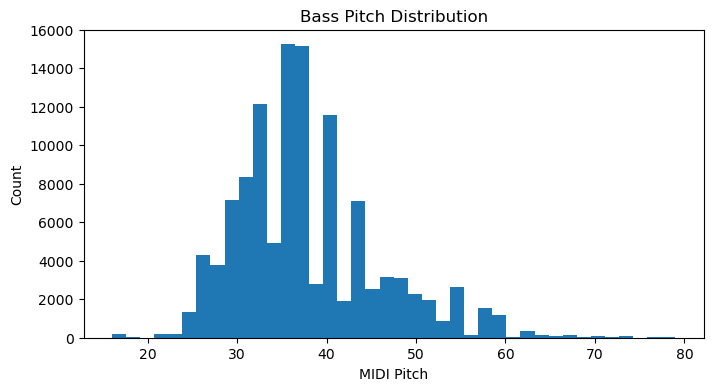

In [13]:
all_bass_pitches = all_bass.flatten()
all_bass_pitches = all_bass_pitches[all_bass_pitches > 0] - 1

plt.figure(figsize=(8, 4))
plt.hist(all_bass_pitches, bins=40)
plt.title("Bass Pitch Distribution")
plt.xlabel("MIDI Pitch")
plt.ylabel("Count")
plt.show()

# Converting MIDI Files into 16-Step Grid Representations

## Goal

The purpose of this preprocessing step is to convert raw MIDI files into a structured symbolic representation that can be used for machine learning models such as LSTMs or Transformers.

Our Task 2 objective is:

> Given a base melody line and BPM, generate an 80s synth-pop style accompaniment consisting of basslines and drum grooves.

To achieve this, we first transform MIDI tracks into fixed-size 16-step grids.

---

# Why Use a 16-Step Grid?

Most 80s synth-pop music follows a regular 4/4 rhythmic structure with repetitive drum machine patterns and looping basslines.

A 16-step grid divides one bar into 16 equal subdivisions:

```text
1 e & a 2 e & a 3 e & a 4 e & a

In [14]:
import pretty_midi
import numpy as np

STEPS_PER_BAR = 16
BARS_PER_SEGMENT = 4
STEPS_PER_SEGMENT = STEPS_PER_BAR * BARS_PER_SEGMENT

DRUM_MAP = {
    36: 0,  # Kick
    38: 1,  # Snare
    40: 1,  # Snare
    42: 2,  # Closed Hi-Hat
    44: 2,  # Pedal Hi-Hat
    46: 2,  # Open Hi-Hat
}

def get_bpm(pm):
    tempo_changes, tempi = pm.get_tempo_changes()
    if len(tempi) == 0:
        return 120
    return float(tempi[0])

def step_duration_seconds(bpm):
    beats_per_bar = 4
    seconds_per_beat = 60.0 / bpm
    return seconds_per_beat / 4  # 16th note

def instrument_name(inst):
    return (inst.name or "").lower()

def is_drum_track(inst):
    return inst.is_drum

def is_bass_track(inst):
    name = instrument_name(inst)
    return "bass" in name or (32 <= inst.program <= 39 and not inst.is_drum)

def is_melody_track(inst):
    name = instrument_name(inst)
    bad_words = ["bass", "drum", "perc", "pad", "chord"]
    return not inst.is_drum and not any(w in name for w in bad_words)

def notes_to_pitch_grid(notes, start_time, step_sec, num_steps):
    """
    Converts MIDI notes into a pitch grid 

    Representation:
    0 = Rest
    1 ~ 128 = actual MIDI pitch 0 ~ 127 shifted by + 1 
    """
    grid = np.zeros(num_steps, dtype=np.int64)

    for note in notes:
        step = int(round((note.start - start_time) / step_sec))

        if 0 <= step < num_steps:
            grid[step] = note.pitch + 1

    return grid

def drums_to_grid(notes, start_time, step_sec, num_steps):
    grid = np.zeros((num_steps, 3), dtype=np.float32)

    for note in notes:
        step = int(round((note.start - start_time) / step_sec))
        if 0 <= step < num_steps and note.pitch in DRUM_MAP:
            drum_idx = DRUM_MAP[note.pitch]
            grid[step, drum_idx] = 1.0

    return grid

def midi_to_4bar_segments(midi_path):
    pm = pretty_midi.PrettyMIDI(midi_path)
    bpm = get_bpm(pm)
    step_sec = step_duration_seconds(bpm)
    segment_sec = step_sec * STEPS_PER_SEGMENT

    melody_instruments = [i for i in pm.instruments if is_melody_track(i)]
    bass_instruments = [i for i in pm.instruments if is_bass_track(i)]
    drum_instruments = [i for i in pm.instruments if is_drum_track(i)]

    if not melody_instruments or not bass_instruments or not drum_instruments:
        return []

    melody_notes = melody_instruments[0].notes
    bass_notes = bass_instruments[0].notes
    drum_notes = drum_instruments[0].notes

    end_time = pm.get_end_time()
    segments = []

    start = 0.0
    while start + segment_sec <= end_time:
        melody_grid = notes_to_pitch_grid(
            melody_notes, start, step_sec, STEPS_PER_SEGMENT
        )
        bass_grid = notes_to_pitch_grid(
            bass_notes, start, step_sec, STEPS_PER_SEGMENT
        )
        drum_grid = drums_to_grid(
            drum_notes, start, step_sec, STEPS_PER_SEGMENT
        )

        if melody_grid.sum() > 0 and bass_grid.sum() > 0 and drum_grid.sum() > 0:
            segments.append({
                "bpm": bpm,
                "melody": melody_grid,
                "bass": bass_grid,
                "drums": drum_grid
            })

        start += segment_sec

    return segments

## Rule-Based Synth-Pop Baseline Generator

Before training the LSTM model, a rule-based accompaniment system was implemented as a baseline comparison model.

The purpose of this baseline is to generate simple synth-pop style basslines and drum grooves using handcrafted musical rules instead of machine learning.

This baseline is useful because it gives us a non-learning reference point for comparison.

The project can compare:

```text
1. Rule-based bass + rule-based drums
2. LSTM-generated bass + LSTM-generated drums

In [15]:
import pretty_midi
import numpy as np

STEPS_PER_BAR = 16
BARS = 4
TOTAL_STEPS = STEPS_PER_BAR * BARS
REST_TOKEN = 0

DRUM_PITCHES = {
    "kick": 36,
    "snare": 38,
    "closed_hat": 42,
    "open_hat": 46,
}

def step_sec_from_bpm(bpm):
    return (60.0 / bpm) / 4  # 16th note

def estimate_root_from_melody(melody_grid):
    pitch_tokens = [p for p in melody_grid if p > REST_TOKEN]

    if len(pitch_tokens) == 0:
        return 48  # actual MIDI pitch C3 fallback

    actual_pitches = [p - 1 for p in pitch_tokens]
    pitch_classes = [p % 12 for p in actual_pitches]
    root_pc = max(set(pitch_classes), key=pitch_classes.count)

    return 36 + root_pc  # actual MIDI pitch around C2-B2


def generate_rule_based_bass(melody_grid):
    root_actual = estimate_root_from_melody(melody_grid)
    fifth_actual = root_actual + 7
    octave_actual = root_actual + 12

    root = root_actual + 1
    fifth = fifth_actual + 1
    octave = octave_actual + 1

    bass_grid = np.zeros(TOTAL_STEPS, dtype=np.int64)

    pattern = [
        root, 0, root, 0,
        fifth, 0, root, 0,
        octave, 0, fifth, 0,
        root, 0, fifth, 0,
    ]

    for bar in range(BARS):
        start = bar * STEPS_PER_BAR
        bass_grid[start:start + STEPS_PER_BAR] = pattern

    return bass_grid

def generate_rule_based_drums():
    drum_grid = np.zeros((TOTAL_STEPS, 3), dtype=np.int64)

    for step in range(TOTAL_STEPS):
        pos = step % STEPS_PER_BAR

        # Hi-hat on every 8th note
        if pos % 2 == 0:
            drum_grid[step, 2] = 1

        # Kick on beats 1 and 3
        if pos in [0, 8]:
            drum_grid[step, 0] = 1

        # Snare on beats 2 and 4
        if pos in [4, 12]:
            drum_grid[step, 1] = 1

        # Small 80s-style extra kick before beat 4
        if pos == 10:
            drum_grid[step, 0] = 1

    return drum_grid

def add_pitch_grid_to_instrument(instrument, pitch_grid, bpm, velocity=90):
    step_sec = step_sec_from_bpm(bpm)

    for step, pitch_token in enumerate(pitch_grid):
        if pitch_token == REST_TOKEN:
            continue

        actual_pitch = int(pitch_token) - 1

        start = step * step_sec
        end = start + step_sec * 0.9

        note = pretty_midi.Note(
            velocity=velocity,
            pitch=actual_pitch,
            start=start,
            end=end
        )

        instrument.notes.append(note)
        
def add_drum_grid_to_instrument(instrument, drum_grid, bpm):
    step_sec = step_sec_from_bpm(bpm)

    for step in range(drum_grid.shape[0]):
        start = step * step_sec
        end = start + step_sec * 0.5

        kick, snare, hat = drum_grid[step]

        if kick:
            instrument.notes.append(pretty_midi.Note(
                velocity=110,
                pitch=DRUM_PITCHES["kick"],
                start=start,
                end=end
            ))

        if snare:
            instrument.notes.append(pretty_midi.Note(
                velocity=100,
                pitch=DRUM_PITCHES["snare"],
                start=start,
                end=end
            ))

        if hat:
            instrument.notes.append(pretty_midi.Note(
                velocity=75,
                pitch=DRUM_PITCHES["closed_hat"],
                start=start,
                end=end
            ))

def create_rule_based_synthpop_midi(melody_grid, bpm=120, output_path="rule_based_synthpop.mid"):
    pm = pretty_midi.PrettyMIDI(initial_tempo=bpm)

    melody_inst = pretty_midi.Instrument(program=80, name="Melody Synth Lead")
    bass_inst = pretty_midi.Instrument(program=38, name="Generated Synth Bass")
    drum_inst = pretty_midi.Instrument(program=0, is_drum=True, name="Drum Machine")

    bass_grid = generate_rule_based_bass(melody_grid)
    drum_grid = generate_rule_based_drums()

    add_pitch_grid_to_instrument(melody_inst, melody_grid, bpm, velocity=95)
    add_pitch_grid_to_instrument(bass_inst, bass_grid, bpm, velocity=90)
    add_drum_grid_to_instrument(drum_inst, drum_grid, bpm)

    pm.instruments.append(melody_inst)
    pm.instruments.append(bass_inst)
    pm.instruments.append(drum_inst)

    pm.write(output_path)

    return bass_grid, drum_grid

melody_grid = np.zeros(64, dtype=np.int64)

# simple sample melody
melody_grid[0] = 60
melody_grid[4] = 64
melody_grid[8] = 67
melody_grid[12] = 72

melody_grid[16] = 72
melody_grid[20] = 67
melody_grid[24] = 64
melody_grid[28] = 60

bass_grid, drum_grid = create_rule_based_synthpop_midi(
    melody_grid=melody_grid,
    bpm=120,
    output_path="rule_based_synthpop.mid"
)

In [16]:
melody_grid = np.zeros(64, dtype=np.int64)

# simple sample melody
melody_grid[0] = 60
melody_grid[4] = 64
melody_grid[8] = 67
melody_grid[12] = 72

melody_grid[16] = 72
melody_grid[20] = 67
melody_grid[24] = 64
melody_grid[28] = 60

bass_grid, drum_grid = create_rule_based_synthpop_midi(
    melody_grid=melody_grid,
    bpm=120,
    output_path="rule_based_synthpop.mid"
)

In [17]:
ipd.display(ipd.Audio("rule_based_synthpop.mid"))

In [18]:
print("Saved MIDI file:")
print("rule_based_synthpop.mid")

Saved MIDI file:
rule_based_synthpop.mid


## Rule-based vs LSTM: Comparison

| | Rule-based | ConditionalBassDrumLSTM |
|---|---|---|
| Training required | No | Yes (30 epochs) |
| Melody-aware | Partial (root pitch only) | Yes (full sequence) |
| Output diversity | None (always identical) | High (stochastic mode) |
| Beat regularity | Perfect (hardcoded) | Lower (learned from data) |
| Bass MAE | 1.43 | **0.21** (det) / **0.27** (stoch) |
| Drum MAE | 0.60 | **0.06** (det) / **0.18** (stoch) |
| Handles syncopation | No | Yes |
| Generates bass | Yes (root/fifth/octave pattern) | Yes (learned from data) |
| Interpretable | Yes | No (black box) |

The rule-based model guarantees rhythmic regularity but produces the same output
regardless of the melody. The LSTM simultaneously learns to generate both bassline
and drum groove conditioned on the full melody sequence, achieving significantly lower
MAE on both outputs compared to the rule-based baseline.


# Conditional LSTM for Bassline and Drum Groove Generation

## Goal

In Task 2, we build a conditional symbolic generation model.

The model receives:

- a base melody line
- BPM information

and predicts:

- a bassline sequence
- a drum groove sequence

This allows us to generate an 80s synth-pop style accompaniment from a given melody.

Each training sample contains:

```text
Input:
melody + BPM

Targets:
bassline + drum groove

In [19]:
class BassDrumDataset(Dataset):
    def __init__(self, melody_grids, bpm_values, bass_grids, drum_grids):
        """
        melody_grids: shape (N, 64)
        bpm_values: shape (N,)
        bass_grids: shape (N, 64)
        drum_grids: shape (N, 64, 3)
        """

        self.melody_grids = torch.LongTensor(melody_grids)
        self.bpm_values = torch.FloatTensor(bpm_values)
        self.bass_grids = torch.LongTensor(bass_grids)
        self.drum_grids = torch.FloatTensor(drum_grids)

    def __len__(self):
        return len(self.melody_grids)

    def __getitem__(self, idx):
        melody = self.melody_grids[idx]
        bpm = self.bpm_values[idx]
        bass = self.bass_grids[idx]
        drums = self.drum_grids[idx]

        bpm_norm = (bpm - 120.0) / 40.0

        return melody, bpm_norm, bass, drums

## Conditional LSTM Architecture

The `ConditionalBassDrumLSTM` model is a conditional sequence generation model designed to generate synth-pop accompaniment from:

```text
Input:
melody sequence + BPM

Outputs:
bassline sequence + drum groove sequence

In [20]:
import torch.nn as nn

class ConditionalBassDrumLSTM(nn.Module):
    def __init__(
        self,
        melody_vocab_size=129,
        bass_vocab_size=129,
        melody_emb_dim=32,
        hidden_dim=128,
        num_layers=2,
        drum_dim=3,
        dropout=0.2
    ):
        super().__init__()

        self.melody_embedding = nn.Embedding(
            num_embeddings=melody_vocab_size,
            embedding_dim=melody_emb_dim,
            padding_idx=REST_TOKEN
        )

        self.lstm = nn.LSTM(
            input_size=melody_emb_dim + 1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.bass_head = nn.Linear(hidden_dim, bass_vocab_size)
        self.drum_head = nn.Linear(hidden_dim, drum_dim)

    def forward(self, melody, bpm):
        batch_size, seq_len = melody.shape

        melody_emb = self.melody_embedding(melody)

        bpm_feature = bpm.view(batch_size, 1, 1)
        bpm_feature = bpm_feature.repeat(1, seq_len, 1)

        x = torch.cat([melody_emb, bpm_feature], dim=-1)

        lstm_out, _ = self.lstm(x)

        bass_logits = self.bass_head(lstm_out)
        drum_logits = self.drum_head(lstm_out)

        return bass_logits, drum_logits

## Why LSTM over Transformer?

An LSTM was chosen over a Transformer architecture for three reasons:

1. **Sequence length**: At 64 steps, sequences are short enough that LSTMs handle
   them well without the memory issues or positional encoding complexity of Transformers.

2. **Dataset size**: With ~4,882 training segments, a Transformer's self-attention
   would likely overfit. LSTMs generalize better on smaller datasets.

3. **Simplicity**: The LSTM is easier to interpret and debug, making it a more
   appropriate baseline for this task.

A Transformer encoder-decoder with cross-attention between melody and drum sequences
would be a natural extension given more data.


## LSTM Training Procedure

The function `train_conditional_bass_drum_lstm()` trains the conditional LSTM model to generate both basslines and drum grooves from melody sequences and BPM information.

The training objective is:

```text
Input:
melody + BPM

Targets:
bassline + drum groove

In [21]:
def train_conditional_bass_drum_lstm(
    model,
    train_loader,
    pos_weight,
    num_epochs=20,
    lr=0.001,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model = model.to(device)

    bass_criterion = nn.CrossEntropyLoss()
    
    pos_weight_tensor = torch.FloatTensor(pos_weight).to(device)
    drum_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for melody, bpm, bass, drums in train_loader:
            melody = melody.to(device)
            bpm = bpm.to(device)
            bass = bass.to(device)
            drums = drums.to(device)

            optimizer.zero_grad()

            bass_logits, drum_logits = model(melody, bpm)

            bass_loss = bass_criterion(
                bass_logits.reshape(-1, bass_logits.shape[-1]),
                bass.reshape(-1)
            )

            drum_loss = drum_criterion(drum_logits, drums)

            loss = bass_loss + drum_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

    return model

## Bassline and Drum Groove Generation

After training the conditional LSTM model, new accompaniment patterns can be generated from:

```text
Input:
melody + BPM

Outputs:
bassline + drum groove

### 1. Deterministic Generation
Uses class-specific thresholds for kick, snare, and hi-hat prediction.

Advantages:
- stable and reproducible output
- prevents hi-hat collapse
- easier evaluation

Limitation:
- same melody always produces the same groove


In [22]:
def generate_bass_and_drums_rest_penalty(
    model,
    melody_grid,
    bpm,
    temperature=0.4,
    rest_penalty=1.5,
    drum_thresholds=np.array([0.46, 0.40, 0.50]),
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model.eval()
    model = model.to(device)

    melody = torch.LongTensor(melody_grid).unsqueeze(0).to(device)
    bpm_norm = torch.FloatTensor([(bpm - 120.0) / 40.0]).to(device)

    with torch.no_grad():
        bass_logits, drum_logits = model(melody, bpm_norm)

        bass_logits[:, :, 0] -= rest_penalty      # REST 억제
        bass_logits = bass_logits / temperature   # 분포 sharpen

        bass_probs = torch.softmax(bass_logits, dim=-1)
        bass_pred = torch.multinomial(
            bass_probs.view(-1, bass_probs.shape[-1]),
            num_samples=1
        ).view(1, -1).squeeze(0).cpu().numpy()

        drum_probs = torch.sigmoid(drum_logits).squeeze(0).cpu().numpy()

    drum_pred = (drum_probs > drum_thresholds.reshape(1, 3)).astype(np.int64)
    return bass_pred, drum_pred

### 2. Stochastic Generation

Instead of always selecting the most likely output, stochastic generation samples from the model probability distribution.

Advantages:

- generates multiple accompaniment variations
- increases rhythmic diversity
- produces less repetitive outputs

Limitations:

- occasionally produces noisy patterns
- less predictable than deterministic generation

Temperature scaling is used to control generation randomness.

Higher temperature:

```text
more random
more diverse

In [23]:
def generate_bass_and_drums_stochastic(
    model,
    melody_grid,
    bpm,
    temperature=1.0,
    drum_scale=np.array([0.65, 0.5, 0.83]),
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model.eval()
    model = model.to(device)

    melody = torch.LongTensor(melody_grid).unsqueeze(0).to(device)
    bpm_norm = torch.FloatTensor(
        [(bpm - 120.0) / 40.0]
    ).to(device)

    with torch.no_grad():
        bass_logits, drum_logits = model(melody, bpm_norm)

        bass_logits = bass_logits / temperature
        bass_probs = torch.softmax(bass_logits, dim=-1)
        bass_pred = torch.multinomial(
            bass_probs.view(-1, bass_probs.shape[-1]),
            num_samples=1
        ).view(1, -1).squeeze(0).cpu().numpy()

        drum_probs = torch.sigmoid(drum_logits).squeeze(0).cpu().numpy()
        drum_probs = drum_probs * drum_scale.reshape(1, 3)   # ← 추가

    drum_pred = np.random.binomial(1, drum_probs).astype(np.int64)
    return bass_pred, drum_pred

## Final MIDI Reconstruction from LSTM Bass and Drum Generation

After generating bassline and drum patterns using the trained conditional LSTM model, the predicted symbolic sequences are converted back into a playable MIDI arrangement.

The function:

```python
create_lstm_midi(...)

In [24]:
def create_lstm_midi(
    melody_grid,
    bass_pred,
    drum_pred,
    bpm=120,
    output_path="lstm_output.mid"
):
    pm = pretty_midi.PrettyMIDI(initial_tempo=bpm)

    melody_inst = pretty_midi.Instrument(
        program=80,
        name="Melody Synth Lead"
    )

    bass_inst = pretty_midi.Instrument(
        program=38,
        name="LSTM Bass"
    )

    drum_inst = pretty_midi.Instrument(
        program=0,
        is_drum=True,
        name="LSTM Drums"
    )

    add_pitch_grid_to_instrument(
        melody_inst,
        melody_grid,
        bpm
    )

    add_pitch_grid_to_instrument(
        bass_inst,
        bass_pred,
        bpm
    )

    add_drum_grid_to_instrument(
        drum_inst,
        drum_pred,
        bpm
    )

    pm.instruments.append(melody_inst)
    pm.instruments.append(bass_inst)
    pm.instruments.append(drum_inst)

    pm.write(output_path)

## Train / Validation Dataset Split

Before training the conditional LSTM model, the dataset is divided into:

```text
1. Training Set
2. Validation Set

In [25]:
from sklearn.model_selection import train_test_split

data = np.load(
    "processed/task2_bass_drum_dataset_4bar.npz",
    allow_pickle=True
)

X_melody = data["melodies"]
X_bpm = data["bpms"]
Y_bass = data["bass"]
Y_drums = data["drums"]

(
    melody_train,
    melody_val,
    bpm_train,
    bpm_val,
    bass_train,
    bass_val,
    drums_train,
    drums_val
) = train_test_split(
    X_melody,
    X_bpm,
    Y_bass,
    Y_drums,
    test_size=0.1,
    random_state=42
)

print("melody:", melody_train.shape)
print("bass:", bass_train.shape)
print("drums:", drums_train.shape)

melody: (4015, 64)
bass: (4015, 64)
drums: (4015, 64, 3)


In [26]:
# drums_train shape: (N, 64, 3)
positive_counts = drums_train.sum(axis=(0, 1))
total_counts = drums_train.shape[0] * drums_train.shape[1]
negative_counts = total_counts - positive_counts

pos_weight = np.sqrt(negative_counts / (positive_counts + 1e-8))

print("positive counts:", positive_counts)
print("pos_weight:", pos_weight)

positive counts: [ 59769  33259 112353]
pos_weight: [1.81637514 2.5934589  1.13449431]


## End-to-End Conditional Drum Generation Pipeline

This section combines all previous components into the complete symbolic synth-pop generation pipeline.

The pipeline performs:

```text
Preprocessed Dataset
        ↓
PyTorch Dataset / DataLoader
        ↓
Conditional LSTM Training
        ↓
Drum Groove Generation
        ↓
MIDI Reconstruction
        ↓
Final Synth-Pop MIDI Output

In [27]:
# 1. Load preprocessed dataset
data = np.load("processed/task2_bass_drum_dataset_4bar.npz", allow_pickle=True)

X_melody = data["melodies"]
X_bpm = data["bpms"]
Y_bass = data["bass"]
Y_drums = data["drums"]


torch.manual_seed(42)
np.random.seed(42)


# 2. Dataset / DataLoader
train_dataset = BassDrumDataset(
    melody_train,
    bpm_train,
    bass_train,
    drums_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# 3. Train bass + drum LSTM
model = ConditionalBassDrumLSTM()

model = train_conditional_bass_drum_lstm(
    model,
    train_loader,
    pos_weight=pos_weight,
    num_epochs=30,
    lr=0.001
)

# 4. Select melody + BPM input
sample_melody = X_melody[19]
sample_bpm = float(X_bpm[19])

# 5. Deterministic generation
bass_pred_det, drum_pred_det = generate_bass_and_drums_rest_penalty(
    model,
    sample_melody,
    sample_bpm
)

create_lstm_midi(
    melody_grid=sample_melody,
    bass_pred=bass_pred_det,
    drum_pred=drum_pred_det,
    bpm=sample_bpm,
    output_path="lstm_deterministic.mid"
)

# 6. Stochastic generation
bass_pred_stoch, drum_pred_stoch = generate_bass_and_drums_stochastic(
    model,
    sample_melody,
    sample_bpm,
    temperature=1.0
)

create_lstm_midi(
    melody_grid=sample_melody,
    bass_pred=bass_pred_stoch,
    drum_pred=drum_pred_stoch,
    bpm=sample_bpm,
    output_path="lstm_stochastic.mid"
)


Epoch 1/30, Loss: 3.1359
Epoch 2/30, Loss: 2.8018
Epoch 3/30, Loss: 2.7830
Epoch 4/30, Loss: 2.7339
Epoch 5/30, Loss: 2.6902
Epoch 6/30, Loss: 2.6802
Epoch 7/30, Loss: 2.6753
Epoch 8/30, Loss: 2.6641
Epoch 9/30, Loss: 2.6298
Epoch 10/30, Loss: 2.6094
Epoch 11/30, Loss: 2.5945
Epoch 12/30, Loss: 2.5745
Epoch 13/30, Loss: 2.5574
Epoch 14/30, Loss: 2.5386
Epoch 15/30, Loss: 2.5252
Epoch 16/30, Loss: 2.5133
Epoch 17/30, Loss: 2.5054
Epoch 18/30, Loss: 2.4945
Epoch 19/30, Loss: 2.4850
Epoch 20/30, Loss: 2.4705
Epoch 21/30, Loss: 2.4587
Epoch 22/30, Loss: 2.4428
Epoch 23/30, Loss: 2.4299
Epoch 24/30, Loss: 2.4145
Epoch 25/30, Loss: 2.3999
Epoch 26/30, Loss: 2.3860
Epoch 27/30, Loss: 2.3684
Epoch 28/30, Loss: 2.3540
Epoch 29/30, Loss: 2.3365
Epoch 30/30, Loss: 2.3232


In [28]:
# Side-by-side audio comparison: rule-based vs LSTM deterministic vs LSTM stochastic
print("Rule-based baseline:")
ipd.display(ipd.Audio("rule_based_synthpop.mid"))

print("LSTM (deterministic):")
ipd.display(ipd.Audio("lstm_deterministic.mid"))

print("LSTM (stochastic, temperature=1.0):")
ipd.display(ipd.Audio("lstm_stochastic.mid"))


Rule-based baseline:


LSTM (deterministic):


LSTM (stochastic, temperature=1.0):


In [29]:
from IPython.display import FileLink

print("Download MIDI files:")

display(FileLink("rule_based_synthpop.mid"))
display(FileLink("lstm_deterministic.mid"))
display(FileLink("lstm_stochastic.mid"))

Download MIDI files:


C:\Users\jwl09\CSE153_TASK2\rule_based_synthpop.mid

C:\Users\jwl09\CSE153_TASK2\lstm_deterministic.mid

C:\Users\jwl09\CSE153_TASK2\lstm_stochastic.mid

## Evaluation Metrics

To evaluate the generated accompaniment, we compare both bassline and drum outputs against the real training data.

### 1. Drum Hit Rate Comparison
Compares average kick, snare, and hi-hat activation frequency between:

- real dataset
- rule-based baseline
- deterministic LSTM generation
- stochastic LSTM generation

This shows whether generated drum grooves statistically resemble real synth-pop drum patterns.

---

### 2. Bass Activation Rate Comparison
Compares how often bass notes occur per bar between:

- real basslines
- rule-based bass baseline
- deterministic LSTM bass generation
- stochastic LSTM bass generation

This measures whether the generated bassline density is close to real synth-pop bass tracks.

---

### 3. MAE from Real Distribution
Mean Absolute Error (MAE) measures how far each method deviates from the real dataset distribution.

Lower MAE means the generated accompaniment is statistically closer to real data.

---

### 4. Deterministic vs Stochastic Comparison
Deterministic generation produces stable and reproducible accompaniment.

Stochastic generation samples from model probabilities, allowing the same melody to produce multiple rhythmic and bassline variations.

---
### 5. Loss Weight Sensitivity

The joint loss sums bass and drum objectives with equal weighting (`loss = bass_loss + drum_loss`).

Since the two losses operate on different scales, we sweep a `drum_loss_weight` parameter
to verify that equal weighting is optimal:

```python
loss = bass_loss + w * drum_loss   # w ∈ {0.5, 1.0, 2.0, 3.0}

In [36]:
#Preparing the data
np.random.seed(42)    
torch.manual_seed(42) 
N = 50

real_drum_per_bar = drums_train.mean(axis=(0, 1)) * 16
real_bass_per_bar = (bass_train > 0).mean() * 16

# Rule-based
rule_drum_grid   = generate_rule_based_drums()
rule_drum_rates  = rule_drum_grid.mean(axis=0)
rule_drum_per_bar = rule_drum_rates * 16

rule_bass_list = [generate_rule_based_bass(X_melody[i]) for i in range(N)]
rule_bass_preds = np.array(rule_bass_list)
rule_bass_per_bar = (rule_bass_preds > 0).mean() * 16

# Deterministic (fixed)
det_bass_list, det_drum_list = [], []
for i in range(N):
    b, d = generate_bass_and_drums_rest_penalty(model, X_melody[i], float(X_bpm[i]))
    det_bass_list.append(b)
    det_drum_list.append(d)
det_bass_preds = np.array(det_bass_list)
det_drum_preds = np.array(det_drum_list)
det_drum_per_bar = det_drum_preds.mean(axis=(0, 1)) * 16
det_bass_per_bar = (det_bass_preds > 0).mean() * 16

# Stochastic (fixed)
stoch_bass_list, stoch_drum_list = [], []
for i in range(N):
    b, d = generate_bass_and_drums_stochastic(model, X_melody[i], float(X_bpm[i]))
    stoch_bass_list.append(b)
    stoch_drum_list.append(d)
stoch_bass_preds = np.array(stoch_bass_list)
stoch_drum_preds = np.array(stoch_drum_list)
stoch_drum_per_bar = stoch_drum_preds.mean(axis=(0, 1)) * 16
stoch_bass_per_bar = (stoch_bass_preds > 0).mean() * 16

print("data prepared  N =", N)


data prepared  N = 50


  Drum Hit Rate Comparison  (avg hits per bar, N=50)
  Method                kick   snare     hat
  ------------------------------------------
  Real data             3.72    2.07    7.00 ← goal
  Rule-based            3.00    2.00    8.00
  Deterministic         3.58    2.05    6.97
  Stochastic            3.54    2.10    6.48


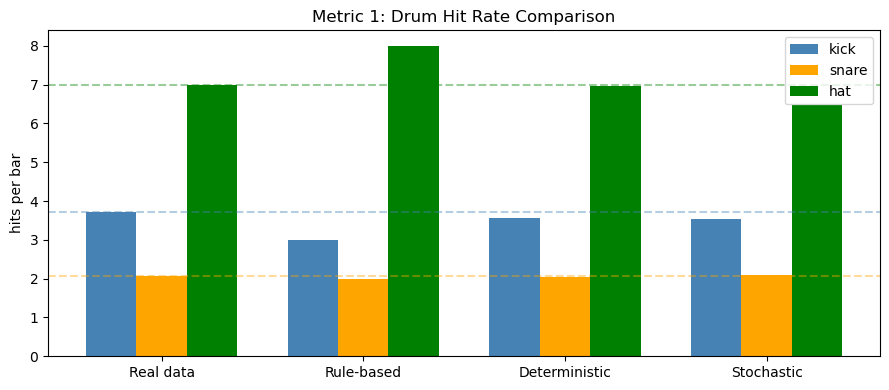

In [37]:
# ── Metric 1: Drum Hit Rate Comparison ──────────────────────────────
methods = {
    "Real data":      real_drum_per_bar,
    "Rule-based":     rule_drum_per_bar,
    "Deterministic":  det_drum_per_bar,
    "Stochastic":     stoch_drum_per_bar,
}

print("=" * 68)
print("  Drum Hit Rate Comparison  (avg hits per bar, N=50)")
print("=" * 68)
print(f"  {'Method':<18}  {'kick':>6}  {'snare':>6}  {'hat':>6}")
print("  " + "-" * 42)
for name, rates in methods.items():
    marker = " ← goal" if name == "Real data" else ""
    print(f"  {name:<18}  {rates[0]:>6.2f}  {rates[1]:>6.2f}  {rates[2]:>6.2f}{marker}")
print("=" * 68)

# 시각화
labels   = list(methods.keys())
kick_v   = [v[0] for v in methods.values()]
snare_v  = [v[1] for v in methods.values()]
hat_v    = [v[2] for v in methods.values()]

x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w, kick_v,  w, label="kick",  color="steelblue")
ax.bar(x,     snare_v, w, label="snare", color="orange")
ax.bar(x + w, hat_v,   w, label="hat",   color="green")

ax.axhline(real_drum_per_bar[0], color="steelblue", linestyle="--", alpha=0.4)
ax.axhline(real_drum_per_bar[1], color="orange",    linestyle="--", alpha=0.4)
ax.axhline(real_drum_per_bar[2], color="green",     linestyle="--", alpha=0.4)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("hits per bar")
ax.set_title("Metric 1: Drum Hit Rate Comparison")
ax.legend()
plt.tight_layout()
plt.show()


  Bass Activation Comparison  (avg notes per bar)
  Method               notes/bar
  ----------------------------------
  Real data                 6.57 ← goal
  Rule-based                8.00
  Deterministic             7.33
  Stochastic                6.83


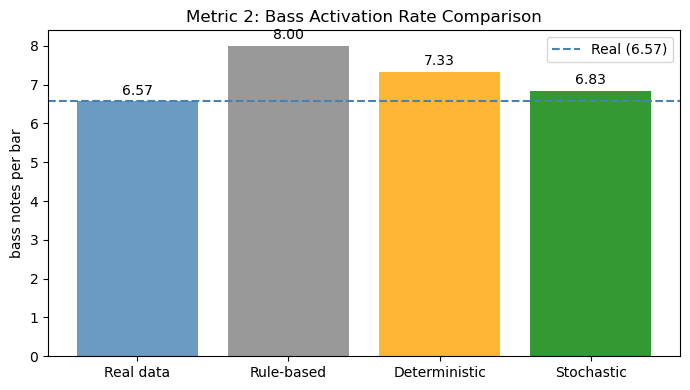

In [38]:
# ── Metric 2: Bass Activation Rate Comparison ────────────────────────
bass_methods = {
    "Real data":     real_bass_per_bar,
    "Rule-based":    rule_bass_per_bar,
    "Deterministic": det_bass_per_bar,
    "Stochastic":    stoch_bass_per_bar,
}

print("=" * 50)
print("  Bass Activation Comparison  (avg notes per bar)")
print("=" * 50)
print(f"  {'Method':<18}  {'notes/bar':>10}")
print("  " + "-" * 34)
for name, val in bass_methods.items():
    marker = " ← goal" if name == "Real data" else ""
    print(f"  {name:<18}  {val:>10.2f}{marker}")
print("=" * 50)

# 시각화
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["steelblue", "gray", "orange", "green"]
bars = ax.bar(bass_methods.keys(), bass_methods.values(), color=colors, alpha=0.8)
ax.axhline(real_bass_per_bar, color="steelblue", linestyle="--", linewidth=1.5, label=f"Real ({real_bass_per_bar:.2f})")

for bar, val in zip(bars, bass_methods.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("bass notes per bar")
ax.set_title("Metric 2: Bass Activation Rate Comparison")
ax.legend()
plt.tight_layout()
plt.show()


  MAE from Real Distribution  (lower = better)
  Method                drum MAE    bass MAE
  --------------------------------------------
  Rule-based              0.5989      1.4312
  Deterministic           0.0628      0.7662
  Stochastic              0.2405      0.2612


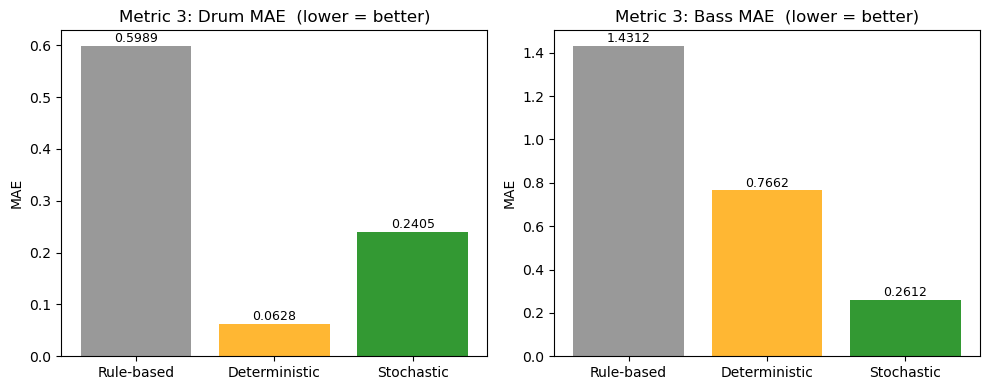

In [39]:
# ── Metric 3: MAE from Real Distribution ────────────────────────────
drum_maes = {
    "Rule-based":    np.abs(rule_drum_per_bar  - real_drum_per_bar).mean(),
    "Deterministic": np.abs(det_drum_per_bar   - real_drum_per_bar).mean(),
    "Stochastic":    np.abs(stoch_drum_per_bar - real_drum_per_bar).mean(),
}
bass_maes = {
    "Rule-based":    abs(rule_bass_per_bar  - real_bass_per_bar),
    "Deterministic": abs(det_bass_per_bar   - real_bass_per_bar),
    "Stochastic":    abs(stoch_bass_per_bar - real_bass_per_bar),
}

print("=" * 54)
print("  MAE from Real Distribution  (lower = better)")
print("=" * 54)
print(f"  {'Method':<18}  {'drum MAE':>10}  {'bass MAE':>10}")
print("  " + "-" * 44)
for name in drum_maes:
    print(f"  {name:<18}  {drum_maes[name]:>10.4f}  {bass_maes[name]:>10.4f}")
print("=" * 54)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, title, mae_dict in [
    (axes[0], "Drum MAE", drum_maes),
    (axes[1], "Bass MAE", bass_maes),
]:
    colors = ["gray", "orange", "green"]
    bars = ax.bar(mae_dict.keys(), mae_dict.values(), color=colors, alpha=0.8)
    for bar, val in zip(bars, mae_dict.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("MAE")
    ax.set_title(f"Metric 3: {title}  (lower = better)")

plt.tight_layout()
plt.show()


  Diversity  (10 runs, same melody idx=10)
  std of total hits — higher = more diverse
  Method                kick std  snare std   hat std  bass std
  ----------------------------------------------------
  Deterministic             0.00       0.00      0.00      2.40
  Stochastic                2.29       1.58      3.10      4.02
  Rule-based                0.00       0.00      0.00      0.00  (always fixed)


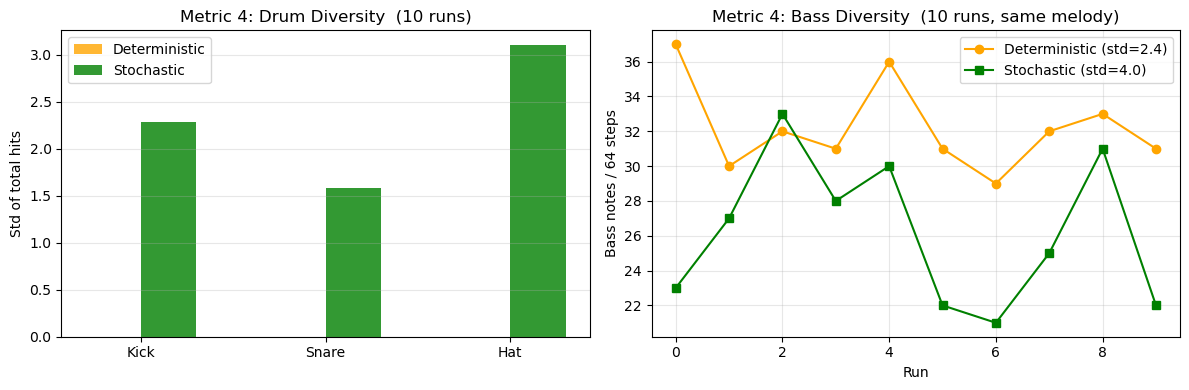

In [40]:
# ── Metric 4: Deterministic vs Stochastic Diversity ──────────────────
REF_IDX = 10
RUNS = 10

det_runs_d, stoch_runs_d = [], []
det_runs_b, stoch_runs_b = [], []

for _ in range(RUNS):
    b_d, d_d = generate_bass_and_drums_rest_penalty(
        model, X_melody[REF_IDX], float(X_bpm[REF_IDX])
    )
    b_s, d_s = generate_bass_and_drums_stochastic(
        model, X_melody[REF_IDX], float(X_bpm[REF_IDX])
    )
    det_runs_d.append(d_d)
    stoch_runs_d.append(d_s)
    det_runs_b.append(b_d)
    stoch_runs_b.append(b_s)

det_drum_arr   = np.array(det_runs_d)    # (10, 64, 3)
stoch_drum_arr = np.array(stoch_runs_d)
det_bass_arr   = np.array(det_runs_b)    # (10, 64)
stoch_bass_arr = np.array(stoch_runs_b)

# ── output values ─────────────────────────────────────────────────────────
print("=" * 62)
print(f"  Diversity  ({RUNS} runs, same melody idx={REF_IDX})")
print("  std of total hits — higher = more diverse")
print("=" * 62)
print(f"  {'Method':<20}  {'kick std':>8}  {'snare std':>9}  {'hat std':>8}  {'bass std':>8}")
print("  " + "-" * 52)

det_std   = det_drum_arr.sum(axis=1).std(axis=0)
stoch_std = stoch_drum_arr.sum(axis=1).std(axis=0)
det_bass_std   = (det_bass_arr > 0).sum(axis=1).std()
stoch_bass_std = (stoch_bass_arr > 0).sum(axis=1).std()

print(f"  {'Deterministic':<20}  {det_std[0]:>8.2f}  {det_std[1]:>9.2f}  {det_std[2]:>8.2f}  {det_bass_std:>8.2f}")
print(f"  {'Stochastic':<20}  {stoch_std[0]:>8.2f}  {stoch_std[1]:>9.2f}  {stoch_std[2]:>8.2f}  {stoch_bass_std:>8.2f}")
print(f"  {'Rule-based':<20}  {'0.00':>8}  {'0.00':>9}  {'0.00':>8}  {'0.00':>8}  (always fixed)")
print("=" * 62)

# ── visualization ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Drum diversity
drum_names = ["Kick", "Snare", "Hat"]
x = np.arange(3)
w = 0.3
axes[0].bar(x - w/2, det_std,   w, label="Deterministic", color="orange", alpha=0.8)
axes[0].bar(x + w/2, stoch_std, w, label="Stochastic",    color="green",  alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(drum_names)
axes[0].set_ylabel("Std of total hits")
axes[0].set_title(f"Metric 4: Drum Diversity  ({RUNS} runs)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Bass diversity 
axes[1].plot(range(RUNS), (det_bass_arr > 0).sum(axis=1),
             marker="o", label=f"Deterministic (std={det_bass_std:.1f})", color="orange")
axes[1].plot(range(RUNS), (stoch_bass_arr > 0).sum(axis=1),
             marker="s", label=f"Stochastic (std={stoch_bass_std:.1f})", color="green")
axes[1].set_xlabel("Run")
axes[1].set_ylabel("Bass notes / 64 steps")
axes[1].set_title(f"Metric 4: Bass Diversity  ({RUNS} runs, same melody)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


  Actual Loss Magnitudes (trained model)
  bass_loss avg : 1.6090
  drum_loss avg : 0.6866
  ratio (bass/drum): 2.34x


  Quick sweep (5 epochs each, N=30 eval samples)
  weight      bass MAE    drum MAE   total MAE
  --------------------------------------------
  0.5           2.2521      0.8761      3.1282
  1.0           2.3771      0.7400      3.1171 ← current
  2.0           2.5771      0.7733      3.3505

  Best weight: 1.0  (total MAE=3.1171)


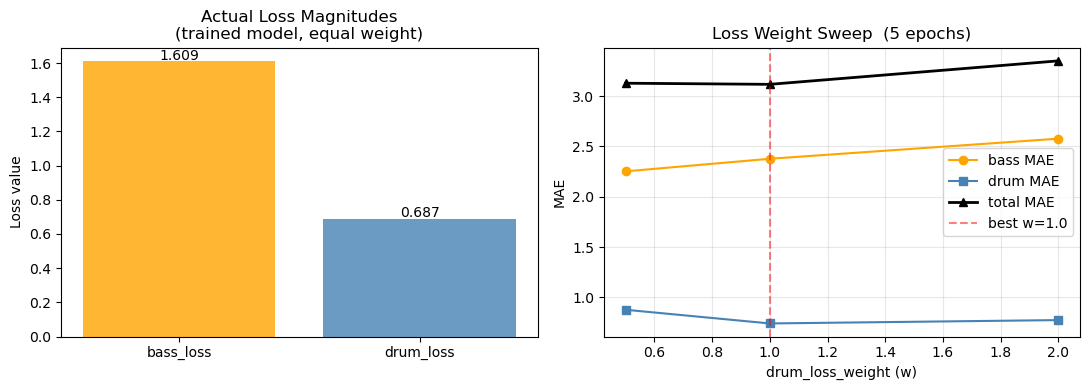

In [41]:
# ── Metric 5: Loss Weight Sensitivity ────────────────────────────────

device = "cuda" if torch.cuda.is_available() else "cpu"
bass_crit = nn.CrossEntropyLoss()
drum_crit = nn.BCEWithLogitsLoss(
    pos_weight=torch.FloatTensor(pos_weight).to(device)
)

model.eval()
bass_losses_raw, drum_losses_raw = [], []

with torch.no_grad():
    for melody, bpm, bass, drums in train_loader:
        melody, bpm, bass, drums = (
            melody.to(device), bpm.to(device),
            bass.to(device), drums.to(device)
        )
        bl, dl = model(melody, bpm)
        bass_losses_raw.append(
            bass_crit(bl.reshape(-1, bl.shape[-1]), bass.reshape(-1)).item()
        )
        drum_losses_raw.append(drum_crit(dl, drums).item())

avg_bass_loss = np.mean(bass_losses_raw)
avg_drum_loss = np.mean(drum_losses_raw)

print("=" * 50)
print("  Actual Loss Magnitudes (trained model)")
print("=" * 50)
print(f"  bass_loss avg : {avg_bass_loss:.4f}")
print(f"  drum_loss avg : {avg_drum_loss:.4f}")
print(f"  ratio (bass/drum): {avg_bass_loss/avg_drum_loss:.2f}x")
print()
print("=" * 50)

weight_candidates = [0.5, 1.0, 2.0]
N_eval = 30
FAST_EPOCHS = 5

print()
print(f"  Quick sweep ({FAST_EPOCHS} epochs each, N={N_eval} eval samples)")
print(f"  {'weight':<8}  {'bass MAE':>10}  {'drum MAE':>10}  {'total MAE':>10}")
print("  " + "-" * 44)

sweep_results = []

for w in weight_candidates:
    torch.manual_seed(42)
    np.random.seed(42)

    m = ConditionalBassDrumLSTM().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.001)
    pw = torch.FloatTensor(pos_weight).to(device)
    dc = nn.BCEWithLogitsLoss(pos_weight=pw)
    bc = nn.CrossEntropyLoss()

    m.train()
    for _ in range(FAST_EPOCHS):
        for mel, bpm_, bas, dru in train_loader:
            mel, bpm_, bas, dru = (
                mel.to(device), bpm_.to(device),
                bas.to(device), dru.to(device)
            )
            opt.zero_grad()
            bl, dl = m(mel, bpm_)
            loss = bc(bl.reshape(-1, bl.shape[-1]), bas.reshape(-1)) + w * dc(dl, dru)
            loss.backward()
            opt.step()

    # evaluation
    bp, dp = [], []
    for i in range(N_eval):
        b, d = generate_bass_and_drums_rest_penalty(m, X_melody[i], float(X_bpm[i]))
        bp.append(b); dp.append(d)

    drum_rates   = np.array(dp).mean(axis=(0, 1)) * 16
    bass_per_bar = (np.array(bp) > 0).mean() * 16
    drum_mae     = np.abs(drum_rates - real_drum_per_bar).mean()
    bass_mae     = abs(bass_per_bar  - real_bass_per_bar)
    total_mae    = drum_mae + bass_mae

    marker = " ← current" if w == 1.0 else ""
    print(f"  {w:<8.1f}  {bass_mae:>10.4f}  {drum_mae:>10.4f}  {total_mae:>10.4f}{marker}")
    sweep_results.append((w, bass_mae, drum_mae, total_mae))

best = min(sweep_results, key=lambda x: x[3])
print()
print(f"  Best weight: {best[0]}  (total MAE={best[3]:.4f})")

# ── visualization ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

weights = [r[0] for r in sweep_results]
bass_maes_sw = [r[1] for r in sweep_results]
drum_maes_sw = [r[2] for r in sweep_results]
total_maes_sw = [r[3] for r in sweep_results]

axes[0].bar(["bass_loss", "drum_loss"], [avg_bass_loss, avg_drum_loss],
            color=["orange", "steelblue"], alpha=0.8)
axes[0].set_title("Actual Loss Magnitudes\n(trained model, equal weight)")
axes[0].set_ylabel("Loss value")
for i, v in enumerate([avg_bass_loss, avg_drum_loss]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

axes[1].plot(weights, bass_maes_sw,  marker="o", label="bass MAE",  color="orange")
axes[1].plot(weights, drum_maes_sw,  marker="s", label="drum MAE",  color="steelblue")
axes[1].plot(weights, total_maes_sw, marker="^", label="total MAE", color="black", linewidth=2)
axes[1].axvline(best[0], color="red", linestyle="--", alpha=0.5, label=f"best w={best[0]}")
axes[1].set_xlabel("drum_loss_weight (w)")
axes[1].set_ylabel("MAE")
axes[1].set_title(f"Loss Weight Sweep  ({FAST_EPOCHS} epochs)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Overall Method Comparison

Rule-based, LSTM Deterministic, and LSTM Stochastic are compared under the same criteria.

| Method | Bass | Drums | Diversity |
|---|---|---|---|
| Rule-based | Fixed root/fifth/octave pattern | Fixed kick/snare/hat pattern | None |
| LSTM Deterministic | rest_penalty + low-temperature sampling | threshold-based | Drum fixed, bass varies slightly |
| LSTM Stochastic | multinomial sampling | binomial sampling with scale | High |

Lower total MAE = closer to real synth-pop distribution.
Higher diversity std = more varied output per melody.


  Overall Comparison  (N=50 samples)
  Method                  bass/bar  kick/bar  snare/bar   hat/bar
  --------------------------------------------------------------
  Real data                   6.57      3.72       2.07      7.00  <- target
  Rule-based                  8.00      3.00       2.00      8.00
  LSTM Deterministic          7.33      3.58       2.05      6.97
  LSTM Stochastic             6.83      3.54       2.10      6.48

  MAE Summary  (lower = better)
  Method                    bass MAE    drum MAE   total MAE   diversity
  ----------------------------------------------------------
  Rule-based                  1.4312      0.5989      2.0301  0.00 (fixed)
  LSTM Deterministic          0.7662      0.0628      0.8290  0.00 (fixed)
  LSTM Stochastic             0.2612      0.2405      0.5017        2.01

  Best total MAE : LSTM Stochastic
  Best bass MAE  : LSTM Stochastic
  Best drum MAE  : LSTM Deterministic
  Diversity gain : stoch=2.01 vs det=0.00 std


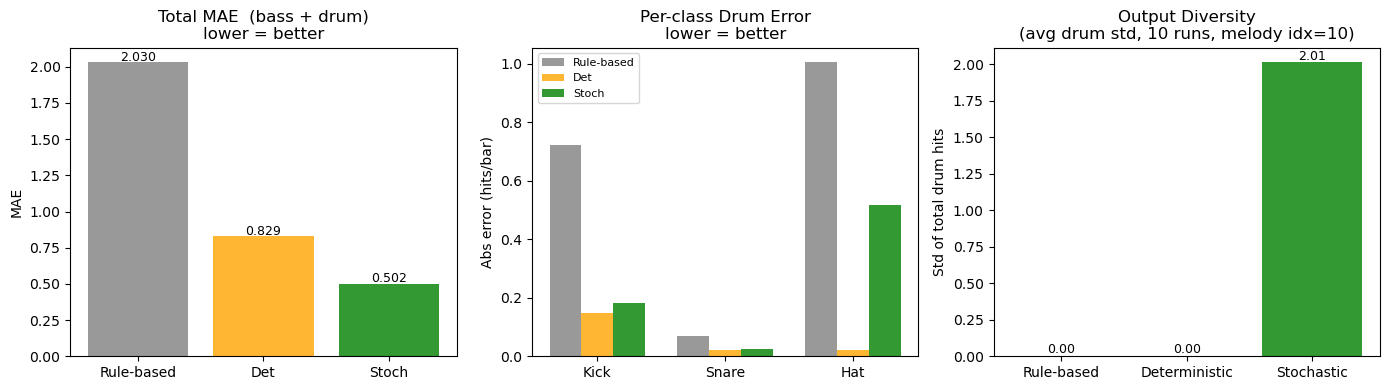

In [43]:
# ── Overall Method Comparison ────────────────────────────────────────
REF_IDX = 10
RUNS = 10

# ── Diversity ────────────────────────────────────────────────────────
det_run_drums, stoch_run_drums = [], []
for _ in range(RUNS):
    _, d = generate_bass_and_drums_rest_penalty(model, X_melody[REF_IDX], float(X_bpm[REF_IDX]))
    _, s = generate_bass_and_drums_stochastic(model,  X_melody[REF_IDX], float(X_bpm[REF_IDX]))
    det_run_drums.append(d)
    stoch_run_drums.append(s)

det_diversity   = np.array(det_run_drums).sum(axis=1).std(axis=0).mean()
stoch_diversity = np.array(stoch_run_drums).sum(axis=1).std(axis=0).mean()

# ── MAE ──────────────────────────────────────────────────────────────
rule_drum_mae  = np.abs(rule_drum_grid.mean(axis=0) * 16 - real_drum_per_bar).mean()
det_drum_mae   = np.abs(det_drum_per_bar  - real_drum_per_bar).mean()
stoch_drum_mae = np.abs(stoch_drum_per_bar - real_drum_per_bar).mean()

rule_bass_mae  = abs(rule_bass_per_bar  - real_bass_per_bar)
det_bass_mae   = abs(det_bass_per_bar   - real_bass_per_bar)
stoch_bass_mae = abs(stoch_bass_per_bar - real_bass_per_bar)

# ── Summary table ─────────────────────────────────────────────────────
print("=" * 76)
print("  Overall Comparison  (N=50 samples)")
print("=" * 76)
print(f"  {'Method':<22}  {'bass/bar':>8}  {'kick/bar':>8}  {'snare/bar':>9}  {'hat/bar':>8}")
print("  " + "-" * 62)
print(f"  {'Real data':<22}  {real_bass_per_bar:>8.2f}  {real_drum_per_bar[0]:>8.2f}  {real_drum_per_bar[1]:>9.2f}  {real_drum_per_bar[2]:>8.2f}  <- target")
print(f"  {'Rule-based':<22}  {rule_bass_per_bar:>8.2f}  {rule_drum_grid.mean(axis=0)[0]*16:>8.2f}  {rule_drum_grid.mean(axis=0)[1]*16:>9.2f}  {rule_drum_grid.mean(axis=0)[2]*16:>8.2f}")
print(f"  {'LSTM Deterministic':<22}  {det_bass_per_bar:>8.2f}  {det_drum_per_bar[0]:>8.2f}  {det_drum_per_bar[1]:>9.2f}  {det_drum_per_bar[2]:>8.2f}")
print(f"  {'LSTM Stochastic':<22}  {stoch_bass_per_bar:>8.2f}  {stoch_drum_per_bar[0]:>8.2f}  {stoch_drum_per_bar[1]:>9.2f}  {stoch_drum_per_bar[2]:>8.2f}")
print("=" * 76)

print()
print("=" * 68)
print("  MAE Summary  (lower = better)")
print("=" * 68)
print(f"  {'Method':<22}  {'bass MAE':>10}  {'drum MAE':>10}  {'total MAE':>10}  {'diversity':>10}")
print("  " + "-" * 58)

rows = [
    ("Rule-based",         rule_bass_mae,  rule_drum_mae,  rule_bass_mae  + rule_drum_mae,  0.0),
    ("LSTM Deterministic", det_bass_mae,   det_drum_mae,   det_bass_mae   + det_drum_mae,   det_diversity),
    ("LSTM Stochastic",    stoch_bass_mae, stoch_drum_mae, stoch_bass_mae + stoch_drum_mae, stoch_diversity),
]

for name, bm, dm, tm, div in rows:
    div_str = f"{div:.2f}" if div > 0 else "0.00 (fixed)"
    print(f"  {name:<22}  {bm:>10.4f}  {dm:>10.4f}  {tm:>10.4f}  {div_str:>10}")
print("=" * 68)

# ── Best method per criterion ─────────────────────────────────────────
best_total = min(rows, key=lambda x: x[3])
best_bass  = min(rows, key=lambda x: x[1])
best_drum  = min(rows, key=lambda x: x[2])

print()
print(f"  Best total MAE : {best_total[0]}")
print(f"  Best bass MAE  : {best_bass[0]}")
print(f"  Best drum MAE  : {best_drum[0]}")
print(f"  Diversity gain : stoch={stoch_diversity:.2f} vs det={det_diversity:.2f} std")

# ── Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Total MAE
methods_label = ["Rule-based", "Det", "Stoch"]
total_vals    = [r[3] for r in rows]
colors        = ["gray", "orange", "green"]

axes[0].bar(methods_label, total_vals, color=colors, alpha=0.8)
for i, v in enumerate(total_vals):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
axes[0].set_title("Total MAE  (bass + drum)\nlower = better")
axes[0].set_ylabel("MAE")

# Per-class drum error
x = np.arange(3)
w = 0.25
drum_names  = ["Kick", "Snare", "Hat"]
rule_err    = np.abs(rule_drum_grid.mean(axis=0) * 16 - real_drum_per_bar)
det_err     = np.abs(det_drum_per_bar  - real_drum_per_bar)
stoch_err   = np.abs(stoch_drum_per_bar - real_drum_per_bar)

axes[1].bar(x - w, rule_err,  w, label="Rule-based",  color="gray",   alpha=0.8)
axes[1].bar(x,     det_err,   w, label="Det",          color="orange", alpha=0.8)
axes[1].bar(x + w, stoch_err, w, label="Stoch",        color="green",  alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(drum_names)
axes[1].set_title("Per-class Drum Error\nlower = better")
axes[1].set_ylabel("Abs error (hits/bar)")
axes[1].legend(fontsize=8)

# Diversity
axes[2].bar(["Rule-based", "Deterministic", "Stochastic"],
            [0.0, det_diversity, stoch_diversity],
            color=["gray", "orange", "green"], alpha=0.8)
for i, v in enumerate([0.0, det_diversity, stoch_diversity]):
    axes[2].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
axes[2].set_title(f"Output Diversity\n(avg drum std, {RUNS} runs, melody idx={REF_IDX})")
axes[2].set_ylabel("Std of total drum hits")

plt.tight_layout()
plt.show()


In [44]:
!jupyter nbconvert --to html task2.ipynb --output workbook.html


[NbConvertApp] Converting notebook task2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 976241 bytes to workbook.html
